### Copenhagen

In [8]:
import pandas as pd

path = '../../../raw-data/social-media/parties_info_scraped.csv'

instagram_cph = pd.read_csv(path, sep=';')

print(instagram_cph.columns)

instagram_cph.head(30)

Index(['Bogstavbetegnelse', 'Listenavn', 'Instagram Tag', 'Follower Count',
       'Number of Posts'],
      dtype='object')


,Bogstavbetegnelse,Listenavn,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,socialdemokratiet,52100.0,2171.0
1,A,Socialdemokratiet Copenhagen,socialdemokratietkbh,591.0,222.0
2,B,Radikale Venstre,radikale,15600.0,2298.0
3,B,Radikale Venstre Copenhagen,radikalekbh,901.0,147.0
4,C,Det Konservative Folkeparti,konservativedk,18600.0,1723.0
5,D,Nye Borgerlige,nyeborgerlige,8759.0,86.0
6,D,Nye Borgerlige Copenhagen,nyeborgerligeungdom_kbh,58.0,1.0
7,E,KaosTV,-,NaN,NaN
8,F,SF - Socialistisk Folkeparti,sf_socialistisk_folkeparti,20800.0,1783.0
9,F,SF - Socialistisk Folkeparti Copenhagen,sfu_kbh,650.0,180.0


In [9]:
path = '../../../raw-data/election-2025/Kommunalvalg_2025_København_25-11-2025 14.54.11.csv'

votes_cph = pd.read_csv(path, sep=';')

print(votes_cph.columns)

votes_cph.head()


Index(['Afstemningsområde', 'Bogstavbetegnelse', 'Listenavn', 'Navn',
       'Stemmetal'],
      dtype='object')


,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,1. 1. Østerbro,A,Socialdemokratiet,Listestemmer,336
1,1. 1. Østerbro,A,Socialdemokratiet,Pernille Rosenkrantz-Theil,339
2,1. 1. Østerbro,A,Socialdemokratiet,Andreas Keil,38
3,1. 1. Østerbro,A,Socialdemokratiet,Laura Rosenvinge,18
4,1. 1. Østerbro,A,Socialdemokratiet,Jakob Hougaard,10


In [10]:
# Only keep general party votes without specific candidates
votes_cph = votes_cph[votes_cph['Navn'] == 'Listestemmer']

# Check a single party before grouping
subset = votes_cph[(votes_cph['Bogstavbetegnelse'] == 'A')]   # choose a party letter

subset_1 = votes_cph[(votes_cph['Listenavn'] == 'Socialdemokratiet')] # choose a party name

print(subset['Stemmetal'].sum())
print(subset_1['Stemmetal'].sum())



15616
15616


In [11]:
# Sum votes from different regions
votes_cph = votes_cph.groupby(
    ['Bogstavbetegnelse', 'Listenavn'],
    as_index=False
)['Stemmetal'].sum()

votes_cph.head(30)


,Bogstavbetegnelse,Listenavn,Stemmetal
0,A,Socialdemokratiet,15616
1,B,Radikale Venstre,15538
2,C,Det Konservative Folkeparti,16702
3,D,Nye Borgerlige,117
4,E,KaosTV,50
5,F,SF - Socialistisk Folkeparti,25426
6,I,Liberal Alliance,10405
7,J,Hampepartiet,249
8,K,Kristendemokraterne,279
9,L,Lokallisten - København,131


In [12]:
# Merge on party ID columns
merged_cph = votes_cph.merge(
    instagram_cph,
    on=['Bogstavbetegnelse', 'Listenavn'],
    how='left'
)

votes_cph.head()

,Bogstavbetegnelse,Listenavn,Stemmetal
0,A,Socialdemokratiet,15616
1,B,Radikale Venstre,15538
2,C,Det Konservative Folkeparti,16702
3,D,Nye Borgerlige,117
4,E,KaosTV,50


In [13]:
# Create columns showing if follower count or post count data is missing
# This helps to identify parties with incomplete Instagram data for further analysis
merged_cph['missing_followers'] = merged_cph['Follower Count'].isna()
merged_cph['missing_posts'] = merged_cph['Number of Posts'].isna()

merged_cph.head(25)

,Bogstavbetegnelse,Listenavn,Stemmetal,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts
0,A,Socialdemokratiet,15616,socialdemokratiet,52100.0,2171.0,False,False
1,B,Radikale Venstre,15538,radikale,15600.0,2298.0,False,False
2,C,Det Konservative Folkeparti,16702,konservativedk,18600.0,1723.0,False,False
3,D,Nye Borgerlige,117,nyeborgerlige,8759.0,86.0,False,False
4,E,KaosTV,50,-,NaN,NaN,True,True
5,F,SF - Socialistisk Folkeparti,25426,sf_socialistisk_folkeparti,20800.0,1783.0,False,False
6,I,Liberal Alliance,10405,liberalalliance,48900.0,1953.0,False,False
7,J,Hampepartiet,249,-,NaN,NaN,True,True
8,K,Kristendemokraterne,279,kd.kristendemokraterne,223.0,128.0,False,False
9,L,Lokallisten - København,131,-,NaN,NaN,True,True


### Frederiksberg

In [14]:
path = '../../../raw-data/social-media/parties_info_frb_scraped.csv'

instagram_frb = pd.read_csv(path, sep=';')

print(instagram_frb.columns)

instagram_frb.head(20)

Index(['Bogstavbetegnelse', 'Listenavn', 'Instagram Tag', 'Follower Count',
       'Number of Posts'],
      dtype='object')


,Bogstavbetegnelse,Listenavn,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,socialdemokratiet,52100.0,2171.0
1,B,Radikale Venstre,radikale,15600.0,2298.0
2,C,Det Konservative Folkeparti,konservativedk,18600.0,1723.0
3,D,Ham Stokken,hamstokken,21.0,17.0
4,E,Hvid-sten Frederiksbergs uafhængige Borgerliste,-,NaN,NaN
5,F,SF - Socialistisk Folkeparti,sf_socialistisk_folkeparti,20800.0,1783.0
6,I,Liberal Alliance,liberalalliance,48900.0,1953.0
7,J,Bitten Vivi Jensen,bittenvivi,692.0,66.0
8,K,Kristendemokraterne,kd.kristendemokraterne,223.0,128.0
9,M,Moderaterne,moderaterne,8468.0,657.0


In [15]:
path = '../../../raw-data/election-2025/Kommunalvalg_2025_Frederiksberg_25-11-2025 14.54.22.csv'

votes_frb = pd.read_csv(path, sep=';')

print(votes_frb.columns)

votes_frb.head()

Index(['Afstemningsområde', 'Bogstavbetegnelse', 'Listenavn', 'Navn',
       'Stemmetal'],
      dtype='object')


,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Listestemmer,310
1,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Michael Vindfeldt,709
2,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Sine Heltberg,68
3,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Malte Mathies Løcke,12
4,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Christina Sylvest-Noer,36


In [16]:
# Only keep general party votes without specific candidates
votes_frb = votes_frb[votes_frb['Navn'] == 'Listestemmer']

# Check a single party before grouping
subset_frb = votes_frb[(votes_frb['Bogstavbetegnelse'] == 'A')]   # choose a party letter

subset_frb_1 = votes_frb[(votes_frb['Listenavn'] == 'Socialdemokratiet')] # choose a party name

print(subset_frb['Stemmetal'].sum())
print(subset_frb_1['Stemmetal'].sum())

3014
3014


In [17]:
# Sum votes from different polling areas
votes_frb = votes_frb.groupby(
    ['Bogstavbetegnelse', 'Listenavn'],
    as_index=False
)['Stemmetal'].sum()

votes_frb.head(30)

,Bogstavbetegnelse,Listenavn,Stemmetal
0,A,Socialdemokratiet,3014
1,B,Radikale Venstre,1758
2,C,Det Konservative Folkeparti,7318
3,D,Ham Stokken,20
4,E,Hvid-sten Frederiksbergs uafhængige Borgerliste,13
5,F,SF - Socialistisk Folkeparti,2575
6,I,Liberal Alliance,984
7,J,Bitten Vivi Jensen,22
8,K,Kristendemokraterne,21
9,M,Moderaterne,225


In [18]:
# Merge on party name and "letter" columns
merged_frb = votes_frb.merge(
    instagram_frb,
    on=['Bogstavbetegnelse', 'Listenavn'],
    how='left'
)

merged_frb.head()

,Bogstavbetegnelse,Listenavn,Stemmetal,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,3014,socialdemokratiet,52100.0,2171.0
1,B,Radikale Venstre,1758,radikale,15600.0,2298.0
2,C,Det Konservative Folkeparti,7318,konservativedk,18600.0,1723.0
3,D,Ham Stokken,20,hamstokken,21.0,17.0
4,E,Hvid-sten Frederiksbergs uafhængige Borgerliste,13,-,NaN,NaN


In [19]:
# Create columns showing if follower count or post count data is missing
# This helps to identify parties with incomplete Instagram data for further analysis
merged_frb['missing_followers'] = merged_frb['Follower Count'].isna()
merged_frb['missing_posts'] = merged_frb['Number of Posts'].isna()

merged_frb.head(30)

,Bogstavbetegnelse,Listenavn,Stemmetal,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts
0,A,Socialdemokratiet,3014,socialdemokratiet,52100.0,2171.0,False,False
1,B,Radikale Venstre,1758,radikale,15600.0,2298.0,False,False
2,C,Det Konservative Folkeparti,7318,konservativedk,18600.0,1723.0,False,False
3,D,Ham Stokken,20,hamstokken,21.0,17.0,False,False
4,E,Hvid-sten Frederiksbergs uafhængige Borgerliste,13,-,NaN,NaN,True,True
5,F,SF - Socialistisk Folkeparti,2575,sf_socialistisk_folkeparti,20800.0,1783.0,False,False
6,I,Liberal Alliance,984,liberalalliance,48900.0,1953.0,False,False
7,J,Bitten Vivi Jensen,22,bittenvivi,692.0,66.0,False,False
8,K,Kristendemokraterne,21,kd.kristendemokraterne,223.0,128.0,False,False
9,M,Moderaterne,225,moderaterne,8468.0,657.0,False,False


### Combined

To strengthen the analysis and provide a more representative view of party performance across the Greater Copenhagen area, I chose to combine the datasets from Copenhagen and Frederiksberg. Although the two municipalities run separate elections, many of the same parties compete in both, and their social media presence extend across municipal boundaries. By aggregating the vote counts for parties appearing in both cities, the dataset better reflects their overall electoral support in the region. At the same time, integrating Frederiksberg-specific parties ensures that the full political landscape is captured. This combined dataset therefore offers a more complete foundation for examining the relationship between social media activity and voting outcomes.

Sidenote: Vote share is typically used when comparing candidates across constituencies with large differences in population or turnout. Because this study includes only two municipalities with relatively similar electoral contexts, raw vote counts provide a more straightforward and meaningful measure of electoral performance. Vote share would not add analytical value in this limited geographic scope.

In [20]:
import numpy as np

# ---------- 1. Clean both input dataframes ----------
for df in (merged_cph, merged_frb):
    df.replace("-", np.nan, inplace=True)
    df.replace({None: np.nan}, inplace=True)

# ---------- 2. Add source labels ----------
merged_cph['source'] = 'cph'
merged_frb['source'] = 'frb'

# Combine datasets
df_all = pd.concat([merged_frb, merged_cph], ignore_index=True)

# Make source sortable so Copenhagen appears first
df_all['source'] = pd.Categorical(df_all['source'], categories=['cph', 'frb'], ordered=True)

# ---------- 4. Group by Listenavn and aggregate ----------
combined = (
    df_all
    .sort_values('source')  # now CPH → FRB
    .groupby('Listenavn', as_index=False)
    .agg({
        'Stemmetal': 'sum',
        'Instagram Tag': 'first',
        'Follower Count': 'first',
        'Number of Posts': 'first'
    })
)

# ---------- 5. Recompute missing flags ----------
combined['missing_followers'] = combined['Follower Count'].isna()
combined['missing_posts']     = combined['Number of Posts'].isna()

# ---------- 6. Cleanup ----------
combined.replace("-", np.nan, inplace=True)
combined.replace({None: np.nan}, inplace=True)

combined.head(30)


,Listenavn,Stemmetal,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts
0,Alternativet,6608,alternativet_,25700.0,1975.0,False,False
1,Bitten Vivi Jensen,22,bittenvivi,692.0,66.0,False,False
2,Borgernes Frederiksberg,17,borgernesfrederiksberg,25.0,30.0,False,False
3,DKP - Kommunisterne,174,NaN,NaN,NaN,True,True
4,Danmarksdemokraterne - Inger Støjberg,1333,partietdanmarksdemokraterne,10800.0,655.0,False,False
5,Dansk Folkeparti,7498,dansk_folkeparti_1995,26200.0,1566.0,False,False
6,Demokraterne - hele Danmark skal leve,127,demokraterne.nu,13.0,6.0,False,False
7,Det Konservative Folkeparti,24020,konservativedk,18600.0,1723.0,False,False
8,Din stemme i København,48,NaN,NaN,NaN,True,True
9,Enhedslisten - De Rød-Grønne,41875,enhedslisten,45600.0,2558.0,False,False


In [21]:
path = "../../preprocessing/instagram/2025-votes-instagram.csv"
combined.to_csv(path, index=False)

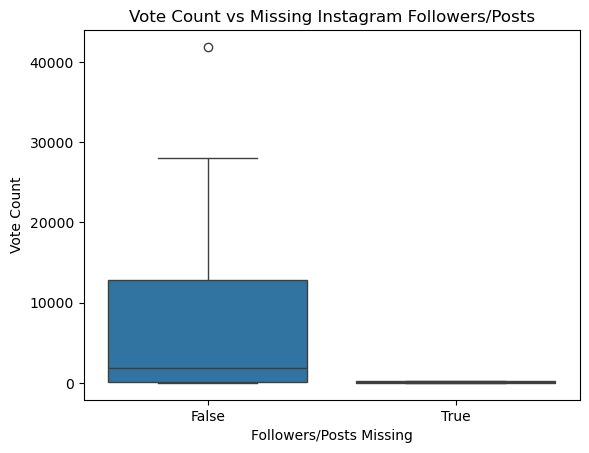

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=combined, x='missing_followers', y='Stemmetal')
plt.title('Vote Count vs Missing Instagram Followers/Posts')
plt.xlabel('Followers/Posts Missing')
plt.ylabel('Vote Count')
plt.show()

The boxplot shows a very large difference in magnitude between parties with missing follower data and those without. The vote counts for the “False” group include extreme high values (in the tens of thousands), while the “True” group stays very close to zero. This large spread causes the plot to be highly skewed and makes it difficult to visually compare the two groups.
To better reveal differences in distribution—especially among lower vote counts—a log-scale transformation will help compress the extreme values and make patterns across both groups more interpretable.

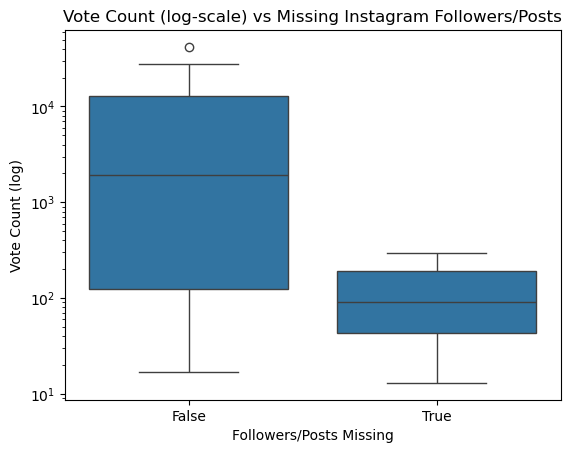

In [23]:
sns.boxplot(data=combined, x='missing_followers', y='Stemmetal')
plt.yscale('log')
plt.title('Vote Count (log-scale) vs Missing Instagram Followers/Posts')
plt.xlabel('Followers/Posts Missing')
plt.ylabel('Vote Count (log)')
plt.show()

The boxplot comparing vote counts for parties with and without Instagram follower and post data shows a substantial and systematic difference. Parties with recorded Instagram data obtain significantly higher vote totals, in contrast, parties with missing Instagram data receive almost no votes. This suggests that missing Instagram data is not due to random measurement error but reflects genuine absence of social media presence among minor parties. Therefore, missingness should be treated as a meaningful feature rather than imputed arbitrarily.

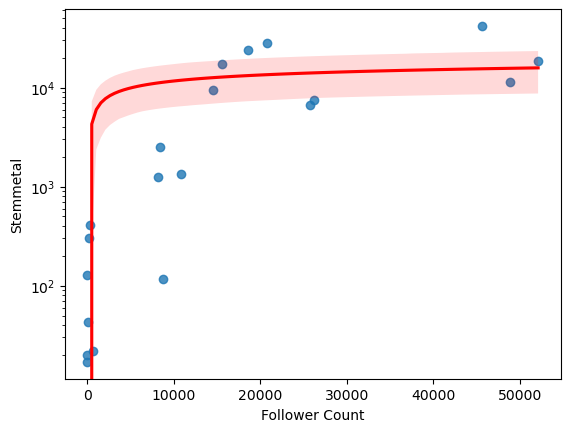

In [24]:
sns.regplot(
    data=combined,
    x='Follower Count',
    y='Stemmetal',
    logx=True,
    scatter_kws={'alpha': 0.8},
    line_kws={'color': 'red'}
)
plt.yscale('log')


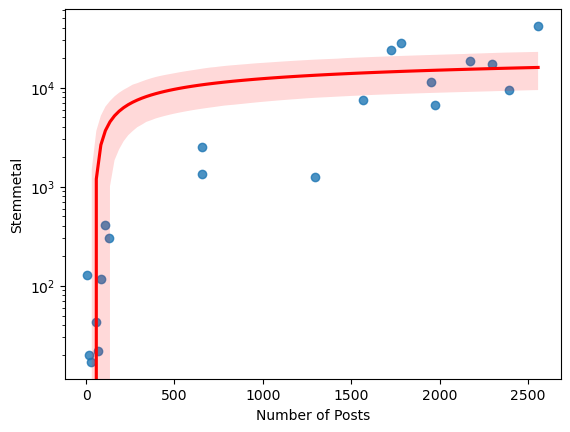

In [25]:
sns.regplot(
    data=combined,
    x='Number of Posts',
    y='Stemmetal',
    logx=True,
    scatter_kws={'alpha': 0.8},
    line_kws={'color': 'red'}
)
plt.yscale('log')

The scatter plots with a log-scaled vote axis indicates a positive but nonlinear relationship between Instagram follower/post count and the number of votes received. While parties with a larger follower/post amount generally achieve higher vote totals, the effect shows diminishing returns: increases in follower/post count lead to substantial gains in votes at low levels, but the relationship flattens for candidates with already-large audiences. Additionally, candidates with few followers/posts display wide variability in vote outcomes, suggesting that factors beyond social media presence also play a significant role. Overall, the pattern shows that Instagram is associated with voting success, but it is not the sole determinant.

### Derived features

Posting Activity: How active the account is relative to its audience size. posts / followers

In [26]:
combined['Posts per Follower'] = combined['Number of Posts'] / combined['Follower Count']


Do politicians with high follower-per-post perform better? followers/posts

In [27]:
combined['Followers per Post'] = combined['Follower Count'] / combined['Number of Posts']

Followers per Post vs Votes

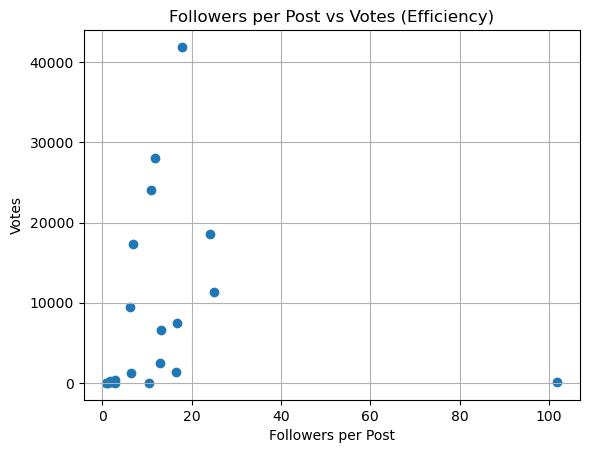

In [28]:
plt.scatter(combined['Followers per Post'], combined['Stemmetal'])
plt.xlabel("Followers per Post")
plt.ylabel("Votes")
plt.title("Followers per Post vs Votes (Efficiency)")
plt.grid(True)
plt.show()


The scatter plot shows no meaningful correlation between Instagram posting efficiency (followers per post) and election performance. While some parties with moderate efficiency values receive many votes, the candidate with the highest efficiency receives almost no votes. This suggests that having a large follower base relative to the number of posts does not translate into electoral success. Instagram efficiency alone is therefore a poor predictor of voting outcomes.

Posts per Follower vs Votes

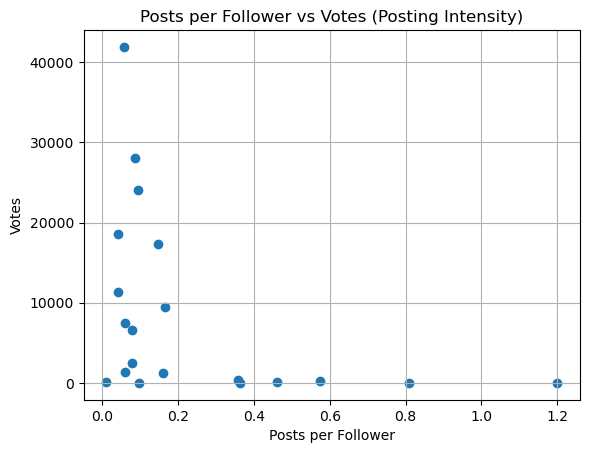

In [29]:
plt.scatter(combined['Posts per Follower'], combined['Stemmetal'])
plt.xlabel("Posts per Follower")
plt.ylabel("Votes")
plt.title("Posts per Follower vs Votes (Posting Intensity)")
plt.grid(True)
plt.show()

The plot demonstrates no meaningful correlation between posting intensity (posts per follower) and vote counts. Parties who received the highest number of votes consistently exhibited low posting intensity, suggesting that high social media output relative to audience size does not improve electoral performance. Conversely, candidates with very high posting intensity received almost no votes, indicating that frequent posting on Instagram cannot compensate for a small follower base. Posting intensity therefore appears to be a poor predictor of political success.

PUT THIS IN THE REPORT We constructed derived measures (followers per post and posts per follower) to capture efficiency and posting intensity. However, scatterplots of these variables against votes showed no clear patterns or additional insights beyond the raw follower and post counts. Therefore, the main analysis focuses on followers and number of posts.